# Tutorial 03 | Schrödinger Bridge — modeling state transitions

Models the transition between two cell-state distributions using entropic
optimal transport. Use this when you have defined **source** and **target**
populations (e.g. young vs old, untreated vs treated).

> For trajectory analysis with pseudotime, use `sjd.tl.fit_drift` instead.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from scjdo.models.schrodinger_bridge import SchrodingerBridge, SchrodingerBridgeConfig
from scjdo.transport.sinkhorn import sinkhorn_divergence
from scjdo.transport.sinkhorn import compute_ot_plan

# ── Configuration ──────────────────────────────────────────────────────────
DIM        = 2       # 2D for visualization; use X_pca dim for real data
N          = 300
EPSILON    = 0.5     # OT regularization (higher = smoother coupling)
N_TRAJ     = 50      # trajectories to simulate
STEPS      = 100     # integration steps
OUTDIR     = 'results/03_bridge/'
os.makedirs(OUTDIR, exist_ok=True)

## 1. Source and target distributions

Synthetic 2D example. For real single-cell data, replace with PCA embeddings of your two populations.

Sinkhorn divergence (source ↔ target): 6.8251


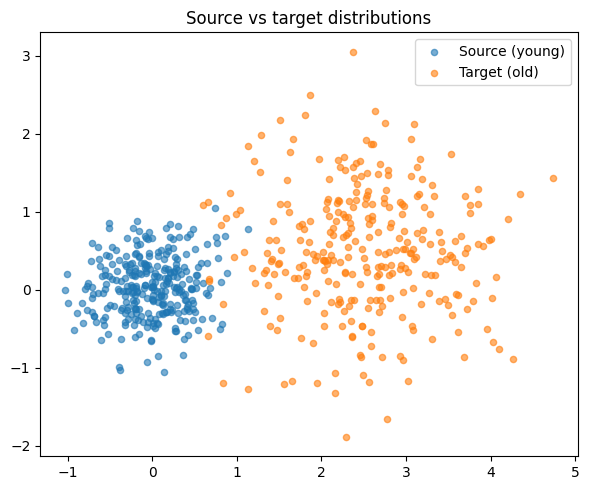

In [2]:
torch.manual_seed(42)
X_young = torch.randn(N, DIM) * 0.4
X_old   = torch.randn(N, DIM) * 0.8 + torch.tensor([2.5, 0.5])

div = sinkhorn_divergence(X_young, X_old, epsilon=EPSILON)
print(f"Sinkhorn divergence (source ↔ target): {div:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(*X_young.T, s=20, alpha=0.6, label='Source (young)')
ax.scatter(*X_old.T,   s=20, alpha=0.6, label='Target (old)')
ax.legend(); ax.set_title('Source vs target distributions')
plt.tight_layout(); plt.savefig(OUTDIR + 'source_target.pdf', dpi=150); plt.show()

## 2. Compute OT coupling

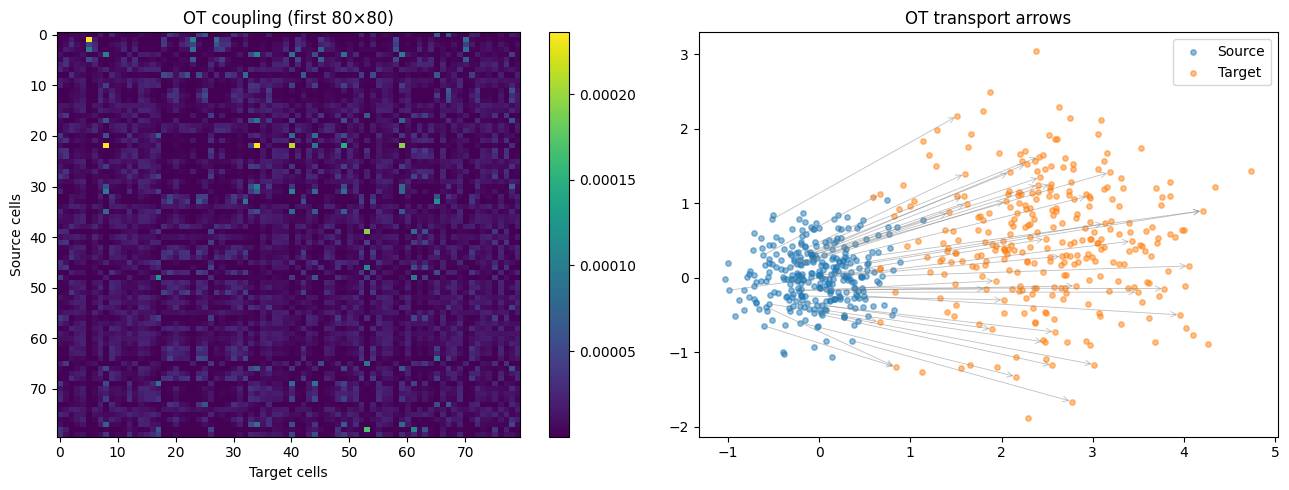

In [3]:
P, _, _ = compute_ot_plan(X_young, X_old, epsilon=EPSILON, max_iter=200)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(P[:80, :80].numpy(), aspect='auto', cmap='viridis')
axes[0].set_title('OT coupling (first 80×80)')
axes[0].set_xlabel('Target cells'); axes[0].set_ylabel('Source cells')
plt.colorbar(axes[0].images[0], ax=axes[0])

# Visualize top transport arrows
n_arrows = 40
src_idx  = np.random.choice(N, n_arrows, replace=False)
tgt_idx  = [int(P[i].argmax()) for i in src_idx]
for s, t in zip(src_idx, tgt_idx):
    axes[1].annotate('', xy=X_old[t].numpy(), xytext=X_young[s].numpy(),
                     arrowprops=dict(arrowstyle='->', color='gray', lw=0.6, alpha=0.5))
axes[1].scatter(*X_young.T, s=15, alpha=0.5, label='Source')
axes[1].scatter(*X_old.T,   s=15, alpha=0.5, label='Target')
axes[1].legend(); axes[1].set_title('OT transport arrows')
plt.tight_layout(); plt.savefig(OUTDIR + 'ot_plan.pdf', dpi=150); plt.show()

## 3. Train the Schrödinger Bridge

Bridge iterations:  15%|▏| 3/20 [00:01<00:09,  1.80it/s, OT=7.2008, bwd=0


✓ Converged at iteration 4 (|ΔCOST| = 0.00e+00 < tol=1.00e-03 for 3 consecutive iters).
Converged: True  |  Iterations: 4


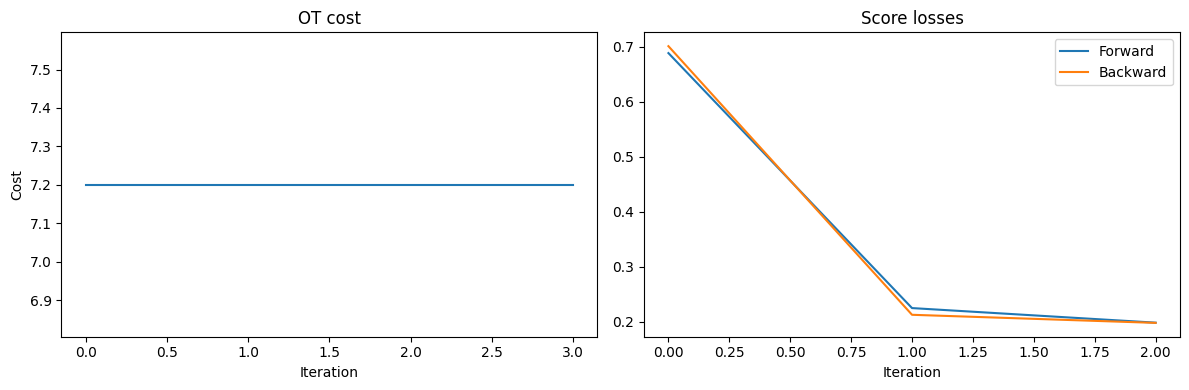

In [4]:
cfg    = SchrodingerBridgeConfig(dim=DIM, hidden=64, depth=3, epsilon=EPSILON,
                                  n_score_steps=300, max_iterations=20)
bridge = SchrodingerBridge(cfg, X_young, X_old)

history = bridge.train_bridge(verbose=True)
print(f"Converged: {history['converged']}  |  Iterations: {history['n_iters']}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['ot_costs']); axes[0].set_title('OT cost')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Cost')
axes[1].plot(history['forward_losses'], label='Forward')
axes[1].plot(history['backward_losses'], label='Backward')
axes[1].legend(); axes[1].set_title('Score losses')
axes[1].set_xlabel('Iteration')
plt.tight_layout(); plt.savefig(OUTDIR + 'training_curves.pdf', dpi=150); plt.show()

## 4. Simulate forward and backward trajectories

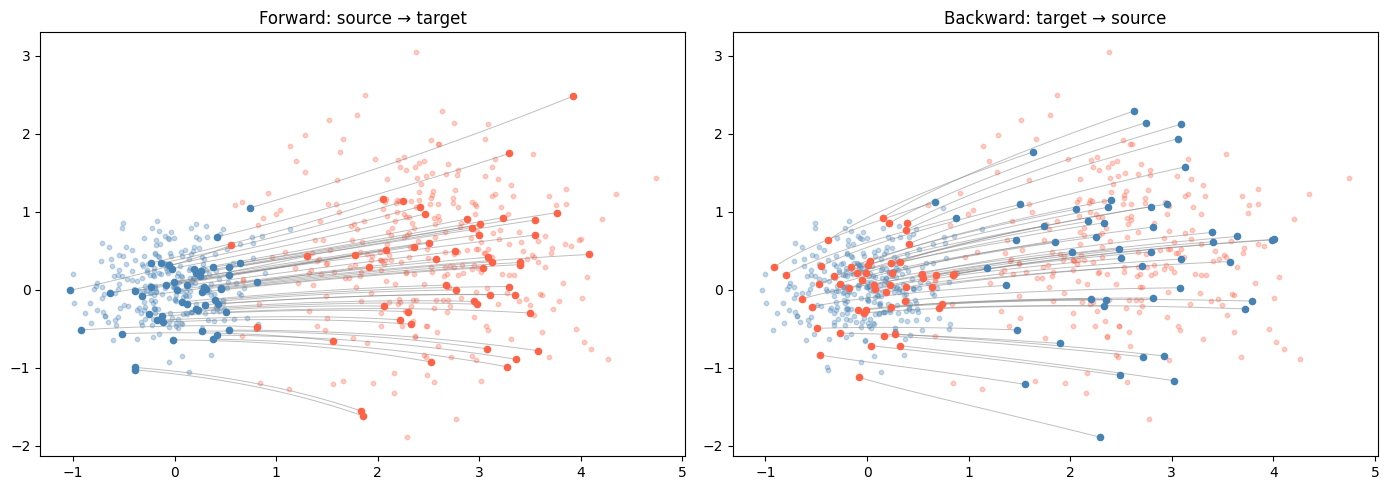

In [5]:
idx_src = torch.randperm(N)[:N_TRAJ]
idx_tgt = torch.randperm(N)[:N_TRAJ]

fwd_traj = bridge.forward_integrate( X_young[idx_src], steps=STEPS, stochastic=False)
bwd_traj = bridge.backward_integrate(X_old[idx_tgt],   steps=STEPS, stochastic=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, traj, title in [(axes[0], fwd_traj, 'Forward: source → target'),
                         (axes[1], bwd_traj, 'Backward: target → source')]:
    ax.scatter(*X_young.T, s=10, alpha=0.3, color='steelblue')
    ax.scatter(*X_old.T,   s=10, alpha=0.3, color='tomato')
    for t in range(traj.shape[0]):
        path = traj[t].numpy()
        ax.plot(path[:, 0], path[:, 1], lw=0.7, alpha=0.5, color='gray')
        ax.scatter(*path[0],  s=20, color='steelblue', zorder=3)
        ax.scatter(*path[-1], s=20, color='tomato',    zorder=3)
    ax.set_title(title)

plt.tight_layout(); plt.savefig(OUTDIR + 'trajectories.pdf', dpi=150); plt.show()

## 5. Round-trip consistency

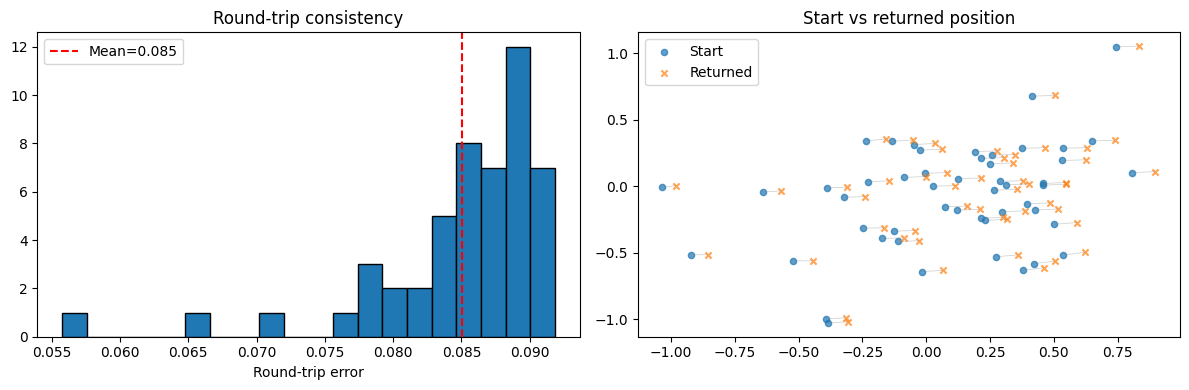

Mean round-trip error: 0.0851  |  Max: 0.0918


In [6]:
x_start = X_young[idx_src]
x_aged  = bridge.forward_integrate( x_start, steps=STEPS, stochastic=False)[:, -1, :]
x_back  = bridge.backward_integrate(x_aged,  steps=STEPS, stochastic=False)[:, -1, :]
error   = (x_back - x_start).norm(dim=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(error.numpy(), bins=20, edgecolor='k')
axes[0].axvline(error.mean(), ls='--', color='r', label=f'Mean={error.mean():.3f}')
axes[0].set_xlabel('Round-trip error'); axes[0].legend()
axes[0].set_title('Round-trip consistency')

axes[1].scatter(*x_start.numpy().T, s=20, label='Start',    alpha=0.7)
axes[1].scatter(*x_back.numpy().T,  s=20, label='Returned', alpha=0.7, marker='x')
for s, b in zip(x_start.numpy(), x_back.numpy()):
    axes[1].plot([s[0], b[0]], [s[1], b[1]], lw=0.5, color='gray', alpha=0.4)
axes[1].legend(); axes[1].set_title('Start vs returned position')
plt.tight_layout(); plt.savefig(OUTDIR + 'roundtrip.pdf', dpi=150); plt.show()
print(f"Mean round-trip error: {error.mean():.4f}  |  Max: {error.max():.4f}")

## 6. Save

In [12]:
torch.save({'forward': bridge.forward_net.state_dict(),
            'backward': bridge.backward_net.state_dict(),
            'cfg': cfg, 'history': history},
           OUTDIR + 'bridge_model.pt')
print(f"Saved to {OUTDIR}bridge_model.pt")

Saved to results/03_bridge/bridge_model.pt


## 7. Instability Analysis — Forward vs Backward

For each bridge direction (source→target and target→source), compute the local Jacobian of the drift network at representative states along the trajectory. The **maximum real eigenvalue** Re(λ_max) measures how much small perturbations are amplified — positive = locally unstable.

**Key question:** Is the transition equally sensitive in both directions, or is one direction more fragile? This asymmetry is invisible to trajectory geometry alone but detectable at the operator level.

For real scRNA-seq data the eigenvectors project to gene space via PCA loadings, giving instability-driving genes per direction. In this 2D toy example the 'features' are the two spatial dimensions.

In [13]:
import pandas as pd

T_STEPS = 20
t_vals  = np.linspace(0.05, 0.95, T_STEPS)
step_idx = (t_vals * STEPS).astype(int).clip(0, STEPS)

# Recompute full trajectories (all N_TRAJ cells, forward and backward)
bridge.forward_net.eval()
bridge.backward_net.eval()
fwd_full = bridge.forward_integrate(X_young[idx_src], steps=STEPS, stochastic=False)
bwd_full = bridge.backward_integrate(X_old[idx_tgt],  steps=STEPS, stochastic=False)

max_eig_fwd = np.zeros(T_STEPS)
max_eig_bwd = np.zeros(T_STEPS)
evec_fwd    = np.zeros((T_STEPS, DIM))
evec_bwd    = np.zeros((T_STEPS, DIM))
states_fwd  = np.zeros((T_STEPS, DIM))
states_bwd  = np.zeros((T_STEPS, DIM))

prev_f = prev_b = None

for i, (t_val, si) in enumerate(zip(t_vals, step_idx)):
    t_batch = torch.full((1,), float(t_val))

    # ── Forward ──────────────────────────────────────────────────────
    x_f = fwd_full[:, si, :].mean(0, keepdim=True)          # (1, DIM)
    states_fwd[i] = x_f.squeeze().numpy()
    J_f = bridge.jacobian(x_f, t_batch, forward=True)[0].numpy()
    evals_f, evecs_f = np.linalg.eig(J_f)
    idx_f = int(np.argmax(np.real(evals_f)))
    v_f   = np.real(evecs_f[:, idx_f])
    v_f  /= np.linalg.norm(v_f) + 1e-8
    if prev_f is not None and np.dot(v_f, prev_f) < 0:
        v_f = -v_f
    prev_f = v_f
    max_eig_fwd[i] = float(np.real(evals_f[idx_f]))
    evec_fwd[i]    = v_f

    # ── Backward ─────────────────────────────────────────────────────
    x_b = bwd_full[:, si, :].mean(0, keepdim=True)
    states_bwd[i] = x_b.squeeze().numpy()
    J_b = bridge.jacobian(x_b, t_batch, forward=False)[0].numpy()
    evals_b, evecs_b = np.linalg.eig(J_b)
    idx_b = int(np.argmax(np.real(evals_b)))
    v_b   = np.real(evecs_b[:, idx_b])
    v_b  /= np.linalg.norm(v_b) + 1e-8
    if prev_b is not None and np.dot(v_b, prev_b) < 0:
        v_b = -v_b
    prev_b = v_b
    max_eig_bwd[i] = float(np.real(evals_b[idx_b]))
    evec_bwd[i]    = v_b

peak_t_fwd = float(t_vals[max_eig_fwd.argmax()])
peak_t_bwd = float(t_vals[max_eig_bwd.argmax()])
print(f'Forward  — peak instability: Re(λ)={max_eig_fwd.max():.4f} at t={peak_t_fwd:.2f}')
print(f'Backward — peak instability: Re(λ)={max_eig_bwd.max():.4f} at t={peak_t_bwd:.2f}')

Forward  — peak instability: Re(λ)=0.7639 at t=0.67
Backward — peak instability: Re(λ)=0.7673 at t=0.05


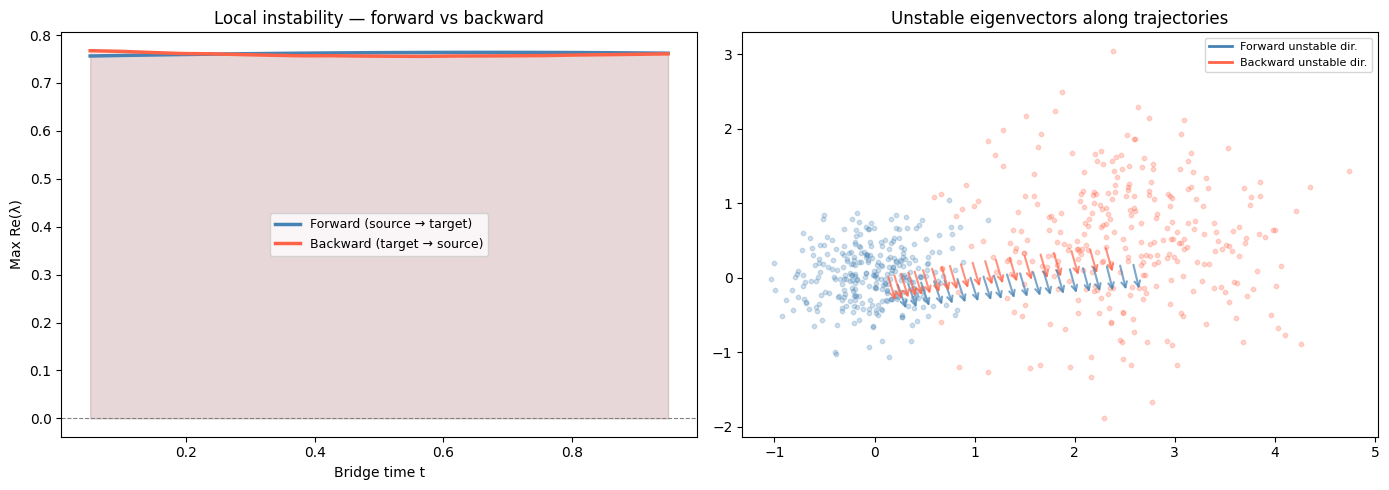

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: instability curves
ax0 = axes[0]
ax0.plot(t_vals, max_eig_fwd, color='steelblue', lw=2.5,
         label='Forward (source → target)')
ax0.plot(t_vals, max_eig_bwd, color='tomato',    lw=2.5,
         label='Backward (target → source)')
ax0.axhline(0, color='gray', lw=0.8, ls='--')
ax0.fill_between(t_vals, max_eig_fwd, 0,
                 where=max_eig_fwd > 0, alpha=0.15, color='steelblue')
ax0.fill_between(t_vals, max_eig_bwd, 0,
                 where=max_eig_bwd > 0, alpha=0.15, color='tomato')
ax0.set_xlabel('Bridge time t'); ax0.set_ylabel('Max Re(λ)')
ax0.set_title('Local instability — forward vs backward')
ax0.legend(fontsize=9)

# Right: unstable directions plotted on 2D embedding
ax1 = axes[1]
ax1.scatter(*X_young.T, s=10, alpha=0.25, color='steelblue')
ax1.scatter(*X_old.T,   s=10, alpha=0.25, color='tomato')

arrow_scale = 0.4
for i in range(T_STEPS):
    # Forward unstable direction (blue arrows)
    x, y   = states_fwd[i]
    dx, dy = evec_fwd[i] * arrow_scale
    ax1.annotate('', xy=(x+dx, y+dy), xytext=(x, y),
                 arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5, alpha=0.7))

    # Backward unstable direction (red arrows)
    x, y   = states_bwd[i]
    dx, dy = evec_bwd[i] * arrow_scale
    ax1.annotate('', xy=(x+dx, y+dy), xytext=(x, y),
                 arrowprops=dict(arrowstyle='->', color='tomato', lw=1.5, alpha=0.7))

# Legend proxies
from matplotlib.lines import Line2D
ax1.legend([
    Line2D([0],[0], color='steelblue', lw=2, label='Forward unstable dir.'),
    Line2D([0],[0], color='tomato',    lw=2, label='Backward unstable dir.'),
], ['Forward unstable dir.', 'Backward unstable dir.'], fontsize=8)
ax1.set_title('Unstable eigenvectors along trajectories')

plt.tight_layout()
plt.savefig(OUTDIR + 'instability_bridge.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# For the 2D toy example 'features' = spatial dimensions.
# For real scRNA-seq, replace dim_labels with gene_names (see below).
dim_labels = [f'Dim{d+1}' for d in range(DIM)]

rows = []
for i in range(T_STEPS):
    top_fwd = dim_labels[int(np.argmax(np.abs(evec_fwd[i])))]
    top_bwd = dim_labels[int(np.argmax(np.abs(evec_bwd[i])))]
    rows.append({
        'bridge_time':       round(float(t_vals[i]), 2),
        'fwd_max_eig':       round(float(max_eig_fwd[i]), 4),
        'fwd_top_feature':   top_fwd,
        'bwd_max_eig':       round(float(max_eig_bwd[i]), 4),
        'bwd_top_feature':   top_bwd,
        'asymmetry(fwd-bwd)': round(float(max_eig_fwd[i]-max_eig_bwd[i]), 4),
    })

df_bridge = pd.DataFrame(rows)
print(df_bridge.to_string(index=False))
df_bridge.to_csv(OUTDIR + 'bridge_instability.csv', index=False)

print(f'\nMost instable bridge time (forward):  t={peak_t_fwd:.2f}')
print(f'Most instable bridge time (backward): t={peak_t_bwd:.2f}')
print(f'Asymmetry (mean fwd-bwd): '
      f'{(max_eig_fwd - max_eig_bwd).mean():.4f}  '
      f'(positive = forward more sensitive)')

 bridge_time  fwd_max_eig fwd_top_feature  bwd_max_eig bwd_top_feature  asymmetry(fwd-bwd)
        0.05       0.7563            Dim2       0.7673            Dim2             -0.0110
        0.10       0.7574            Dim2       0.7660            Dim2             -0.0087
        0.14       0.7584            Dim2       0.7636            Dim2             -0.0052
        0.19       0.7593            Dim2       0.7615            Dim2             -0.0022
        0.24       0.7602            Dim2       0.7608            Dim2             -0.0007
        0.29       0.7609            Dim2       0.7592            Dim2              0.0017
        0.33       0.7616            Dim2       0.7578            Dim2              0.0038
        0.38       0.7622            Dim2       0.7567            Dim2              0.0055
        0.43       0.7627            Dim2       0.7568            Dim2              0.0059
        0.48       0.7631            Dim2       0.7562            Dim2              0.0069

### Extracting instability genes from real scRNA-seq data

When the bridge is trained on PCA embeddings of real cells (`basis='X_pca'`, `DIM=n_pcs`), project the eigenvectors to gene space using PCA loadings — identical to the DriftField approach:

```python
pca_loadings = adata.varm['PCs'].astype('float32')   # (n_genes, n_pcs)
gene_names   = list(adata.var_names)

# Project eigenvectors at each time step → gene scores
gene_scores_fwd = np.stack([pca_loadings @ evec_fwd[i] for i in range(T_STEPS)])
gene_scores_bwd = np.stack([pca_loadings @ evec_bwd[i] for i in range(T_STEPS)])

# Top instability genes — forward direction
mean_fwd   = np.abs(gene_scores_fwd[max_eig_fwd > 0.05]).mean(0)
top_genes_fwd = [gene_names[j] for j in np.argsort(mean_fwd)[::-1][:20]]

# Top instability genes — backward direction
mean_bwd   = np.abs(gene_scores_bwd[max_eig_bwd > 0.05]).mean(0)
top_genes_bwd = [gene_names[j] for j in np.argsort(mean_bwd)[::-1][:20]]

# Genes unique to forward (aging-specific instability drivers)
fwd_only = set(top_genes_fwd) - set(top_genes_bwd)
bwd_only = set(top_genes_bwd) - set(top_genes_fwd)
```